# 06 · Site Classification

**Input :** `data/processed/analysis_panel.parquet`
**Outputs:** `data/processed/analysis_panel.parquet` (updated) · `data/processed/site_classification.parquet`

Classify all 132 well-covered AWV stations into **commuter**, **mixed**, or **leisure**
using three behavioural metrics:
1. Weekday / weekend ratio
2. Peak-hour share (avg peak_ratio)
3. School holiday retention

Steps: 0 Load · 1 Metrics · 2 Normalise · 3 Classify · 4 Merge back ·
5 Validate · 6 Figures · 7 Save · 8 Summary

## 0. Imports & Load Data

In [6]:
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

ROOT      = Path().resolve().parent
PROCESSED = ROOT / "data" / "processed"
FIGS      = ROOT / "outputs" / "figures"

panel = pd.read_parquet(PROCESSED / "analysis_panel.parquet")
panel["date"] = pd.to_datetime(panel["date"])

panel_good = panel[panel["low_coverage"] == False].copy()

n_total = panel["site ID"].nunique()
n_good  = panel_good["site ID"].nunique()
n_low   = n_total - n_good

print(f"Total stations        : {n_total}")
print(f"Well-covered stations : {n_good}")
print(f"Low-coverage stations : {n_low}")

Total stations        : 149
Well-covered stations : 132
Low-coverage stations : 17


## 1. Compute Station-Level Classification Metrics

Three metrics that proxy commute vs leisure behaviour:
- **Weekday/weekend ratio** — commuters keep cycling Mon–Fri, leisure cyclists peak on weekends
- **Peak-hour ratio** — commuters concentrate trips around 07–09h and 17–18h
- **School holiday retention** — commuters are unaffected; leisure stations drop when schools close

In [7]:
# Base aggregation — avg_daily, avg_peak_ratio, lon, lat per station
base = (
    panel_good.groupby(["site ID", "naam", "gemeente"], as_index=False)
    .agg(
        avg_daily      = ("aantal",      "mean"),
        avg_peak_ratio = ("peak_ratio",  "mean"),
        lon            = ("lon",         "first"),
        lat            = ("lat",         "first"),
    )
)

# Separate filtered groupbys (faster than per-group lambdas on 96k rows)
wd = (panel_good[~panel_good["is_weekend"]]
      .groupby("site ID")["aantal"].mean().rename("avg_weekday"))
we = (panel_good[ panel_good["is_weekend"]]
      .groupby("site ID")["aantal"].mean().rename("avg_weekend"))
sd = (panel_good[~panel_good["is_school_holiday"]]
      .groupby("site ID")["aantal"].mean().rename("avg_schoolday"))
sh = (panel_good[ panel_good["is_school_holiday"]]
      .groupby("site ID")["aantal"].mean().rename("avg_schoolhol"))

site_stats = (
    base
    .merge(wd.reset_index(), on="site ID", how="left")
    .merge(we.reset_index(), on="site ID", how="left")
    .merge(sd.reset_index(), on="site ID", how="left")
    .merge(sh.reset_index(), on="site ID", how="left")
)

# Metric 1: weekday / weekend ratio  (clip to avoid outlier inflation)
site_stats["weekday_weekend_ratio"] = (
    site_stats["avg_weekday"] / site_stats["avg_weekend"]
).clip(0, 10)

# Metric 3: school retention  (avg during school holidays / avg during school days)
# close to 1.0 = commuter (unaffected); well below 1.0 = leisure (drops in holidays)
site_stats["school_retention"] = (
    site_stats["avg_schoolhol"] / site_stats["avg_schoolday"]
).clip(0, 2)

print("Key metric distributions:")
desc_cols = ["weekday_weekend_ratio", "avg_peak_ratio", "school_retention"]
display(site_stats[desc_cols].describe().round(3))

Key metric distributions:


,weekday_weekend_ratio,avg_peak_ratio,school_retention
count,132.000,132.000,132.000
mean,1.574,0.269,1.030
std,0.725,0.046,0.221
min,0.690,0.138,0.710
25%,1.306,0.237,0.901
50%,1.484,0.274,0.981
75%,1.682,0.301,1.076
max,7.476,0.383,2.000


## 2. Normalise and Score

In [8]:
metrics = ["weekday_weekend_ratio", "avg_peak_ratio", "school_retention"]
scaler  = MinMaxScaler()
site_stats[["norm_wwr", "norm_peak", "norm_school"]] = scaler.fit_transform(
    site_stats[metrics]
)

# Composite score: weekday pattern and peak share equally dominant
site_stats["commute_score"] = (
    site_stats["norm_wwr"]    * 0.4 +
    site_stats["norm_peak"]   * 0.4 +
    site_stats["norm_school"] * 0.2
)

print("commute_score distribution:")
print(site_stats["commute_score"].describe().round(3))

commute_score distribution:
count    132.000
mean       0.315
std        0.080
min        0.100
25%        0.268
50%        0.317
75%        0.353
max        0.735
Name: commute_score, dtype: float64


## 3. Classify Stations into Three Groups

Tertile split (p33 / p67) on `commute_score`:
- **commuter** — top third
- **mixed** — middle third
- **leisure** — bottom third

In [9]:
p33 = site_stats["commute_score"].quantile(0.33)
p67 = site_stats["commute_score"].quantile(0.67)

def classify(score):
    if score >= p67:   return "commuter"
    elif score >= p33: return "mixed"
    else:              return "leisure"

site_stats["site_type"] = site_stats["commute_score"].apply(classify)

print(f"Tertile thresholds : p33 = {p33:.3f}  |  p67 = {p67:.3f}")
print()
print("Stations per type:")
print(site_stats["site_type"].value_counts().sort_index())

SHOW_COLS = ["naam", "gemeente", "commute_score",
             "weekday_weekend_ratio", "avg_peak_ratio", "school_retention"]

print("Top 10 commuter stations:")
display(site_stats.nlargest(10, "commute_score")[SHOW_COLS].reset_index(drop=True).round(3))

print("Top 10 leisure stations:")
display(site_stats.nsmallest(10, "commute_score")[SHOW_COLS].reset_index(drop=True).round(3))

sorted_all  = site_stats.sort_values("commute_score", ascending=False).reset_index(drop=True)
sorted_all.index += 1
totem_rank  = sorted_all.index[sorted_all["site ID"] == 107][0]
print(f"Leuven Totem (site ID 107): rank #{totem_rank} out of {len(site_stats)}")
display(site_stats[site_stats["site ID"] == 107][SHOW_COLS + ["site_type"]].round(3))

Tertile thresholds : p33 = 0.294  |  p67 = 0.344

Stations per type:
site_type
commuter    44
leisure     44
mixed       44
Name: count, dtype: int64
Top 10 commuter stations:


,naam,gemeente,commute_score,weekday_weekend_ratio,avg_peak_ratio,school_retention
0,Deinze teller 1,Nazareth,0.735,7.476,0.314,1.018
1,Zaventem totem,Zaventem,0.515,1.949,0.383,0.975
2,Mechelen teller 1,Mechelen,0.488,3.316,0.327,0.869
3,Ieper totem,Ieper,0.454,1.590,0.349,1.069
4,Herent teller 2,Herent,0.446,1.772,0.352,0.912
5,Vilvoorde,Vilvoorde,0.440,1.477,0.354,0.968
6,Zaventem,Zaventem,0.430,1.289,0.354,0.970
7,Evergem 2,Evergem,0.428,2.227,0.330,0.869
8,Gent,Gent,0.425,2.112,0.338,0.807
9,Beersel teller 2,Beersel,0.419,1.290,0.320,1.262


Top 10 leisure stations:


,naam,gemeente,commute_score,weekday_weekend_ratio,avg_peak_ratio,school_retention
0,Maaseik teller 1,Maaseik,0.100,0.772,0.138,1.322
1,Westerlo teller 1,Westerlo,0.159,0.959,0.186,1.128
2,Dendermonde teller 2,Dendermonde,0.164,1.365,0.181,1.059
3,As,As,0.169,0.690,0.154,1.635
4,Westerlo teller 2,Westerlo,0.184,1.210,0.212,0.925
5,Diest teller 2,Diest,0.185,1.308,0.196,1.064
6,Lanaken teller 2,Lanaken,0.188,1.219,0.193,1.145
7,Heers,Heers,0.193,0.746,0.175,1.549
8,Heers teller 1,Heers,0.194,0.746,0.181,1.486
9,Maasmechelen teller 2,Maasmechelen,0.196,1.538,0.201,0.991


Leuven Totem (site ID 107): rank #49 out of 132


,naam,gemeente,commute_score,weekday_weekend_ratio,avg_peak_ratio,school_retention,site_type
101,leuven totem,Leuven,0.343,1.492,0.301,0.9,mixed


## 4. Merge Classification Back to Panel

In [10]:
CLASS_COLS = ["site ID", "commute_score", "site_type",
              "weekday_weekend_ratio", "avg_peak_ratio", "school_retention"]

panel_good = panel_good.merge(site_stats[CLASS_COLS], on="site ID", how="left")

panel_full = panel.merge(
    site_stats[["site ID", "commute_score", "site_type"]],
    on="site ID", how="left"
)
panel_full["site_type"] = panel_full["site_type"].fillna("unclassified")

print(f"panel_good shape : {panel_good.shape}")
print(f"panel_full shape : {panel_full.shape}")
print()
print("site_type distribution in panel_full:")
print(panel_full["site_type"].value_counts())

panel_good shape : (96492, 59)
panel_full shape : (108919, 56)

site_type distribution in panel_full:
site_type
commuter        32164
mixed           32164
leisure         32164
unclassified    12427
Name: count, dtype: int64


## 5. Validate Classification

In [11]:
TYPE_ORDER  = ["commuter", "mixed", "leisure"]
TYPE_COLORS = {"commuter": "steelblue", "mixed": "gold", "leisure": "tomato"}

wd_t = (panel_good[~panel_good["is_weekend"]]
        .groupby("site_type")["aantal"].mean().rename("avg_weekday"))
we_t = (panel_good[ panel_good["is_weekend"]]
        .groupby("site_type")["aantal"].mean().rename("avg_weekend"))
sd_t = (panel_good[~panel_good["is_school_holiday"]]
        .groupby("site_type")["aantal"].mean().rename("avg_schoolday"))
sh_t = (panel_good[ panel_good["is_school_holiday"]]
        .groupby("site_type")["aantal"].mean().rename("avg_schoolhol"))
pr_t = panel_good.groupby("site_type")["peak_ratio"].mean().rename("avg_peak_ratio")

val_table = (
    pd.concat([wd_t, we_t, sd_t, sh_t, pr_t], axis=1)
    .reindex(TYPE_ORDER)
)
val_table["wday_wend_ratio"] = (val_table["avg_weekday"] /
                                 val_table["avg_weekend"])
val_table["school_drop_pct"] = ((1 - val_table["avg_schoolhol"] /
                                      val_table["avg_schoolday"]) * 100)

print("Validation table by site_type:")
display(val_table.round(2))

print()
print("Expected pattern:")
print("  commuter : wday_wend_ratio > 1.5,  high avg_peak_ratio, low school_drop_pct")
print("  leisure  : wday_wend_ratio close to 1, low avg_peak_ratio, high school_drop_pct")

Validation table by site_type:


,avg_weekday,avg_weekend,avg_schoolday,avg_schoolhol,avg_peak_ratio,wday_wend_ratio,school_drop_pct
site_type,,,,,,,
commuter,462.869995,276.519989,421.630005,380.970001,0.31,1.67,9.64
mixed,788.270020,547.950012,722.830017,712.580017,0.27,1.44,1.42
leisure,450.940002,350.779999,414.820007,441.059998,0.22,1.29,-6.33



Expected pattern:
  commuter : wday_wend_ratio > 1.5,  high avg_peak_ratio, low school_drop_pct
  leisure  : wday_wend_ratio close to 1, low avg_peak_ratio, high school_drop_pct


## 6. Visualisations

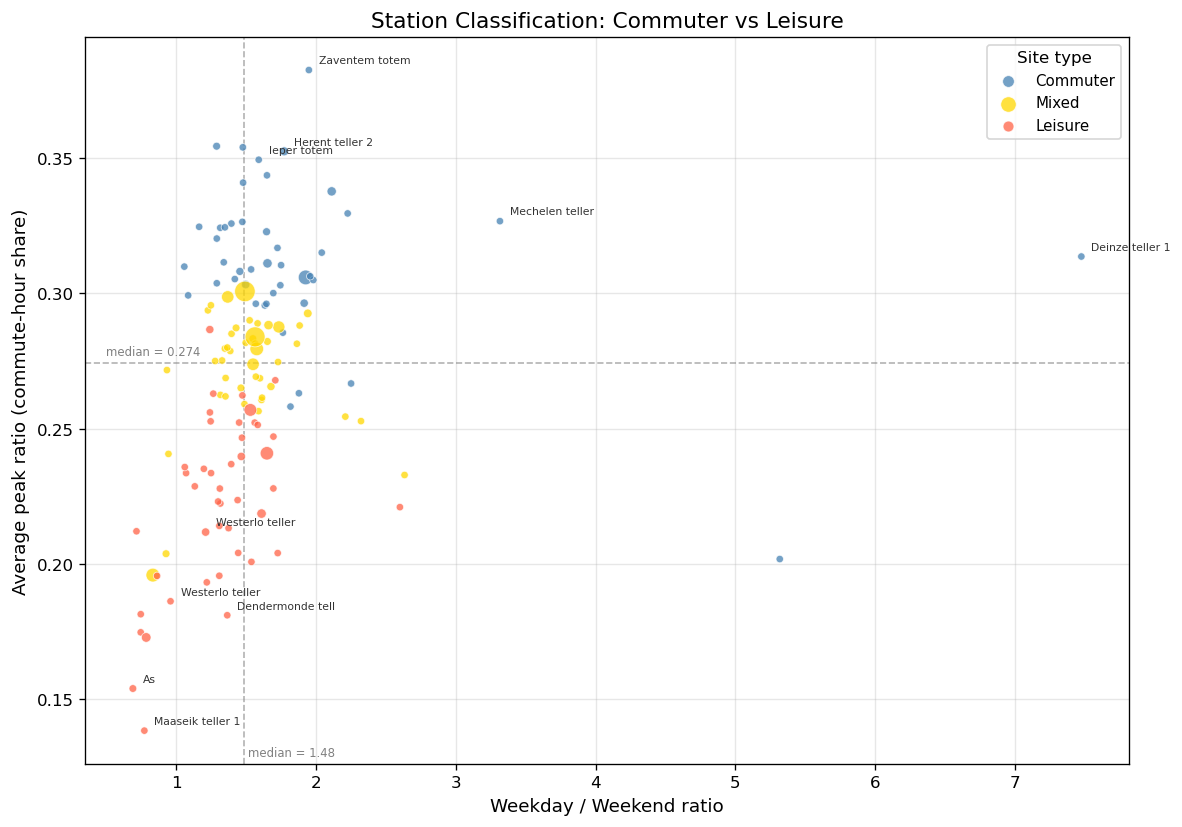

fig10_classification_scatter.png saved.


In [12]:
# ── fig10: scatter weekday_weekend_ratio vs avg_peak_ratio ────────────────────
med_wwr  = site_stats["weekday_weekend_ratio"].median()
med_peak = site_stats["avg_peak_ratio"].median()

fig, ax = plt.subplots(figsize=(10, 7))

for stype, color in TYPE_COLORS.items():
    sub = site_stats[site_stats["site_type"] == stype]
    ax.scatter(
        sub["weekday_weekend_ratio"], sub["avg_peak_ratio"],
        c=color, s=(sub["avg_daily"] / 30).clip(20, 300),
        alpha=0.75, label=stype.title(), edgecolors="white", lw=0.5, zorder=3,
    )

ax.axvline(med_wwr,  color="grey", lw=1, ls="--", alpha=0.6)
ax.axhline(med_peak, color="grey", lw=1, ls="--", alpha=0.6)
ax.text(med_wwr + 0.03, ax.get_ylim()[0] + 0.003,
        f"median = {med_wwr:.2f}", fontsize=7, color="grey")
ax.text(0.02, med_peak + 0.003,
        f"median = {med_peak:.3f}", fontsize=7, color="grey",
        transform=ax.get_yaxis_transform())

# Label top 5 commuter + top 5 leisure
for _, row in pd.concat([site_stats.nlargest(5, "commute_score"),
                          site_stats.nsmallest(5, "commute_score")]).iterrows():
    ax.annotate(
        row["naam"][:16],
        xy=(row["weekday_weekend_ratio"], row["avg_peak_ratio"]),
        fontsize=6.5, xytext=(6, 4), textcoords="offset points", color="#333",
    )

ax.set_xlabel("Weekday / Weekend ratio", fontsize=11)
ax.set_ylabel("Average peak ratio (commute-hour share)", fontsize=11)
ax.set_title("Station Classification: Commuter vs Leisure", fontsize=13)
ax.legend(title="Site type", fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIGS / "fig10_classification_scatter.png", dpi=150)
plt.show()
print("fig10_classification_scatter.png saved.")

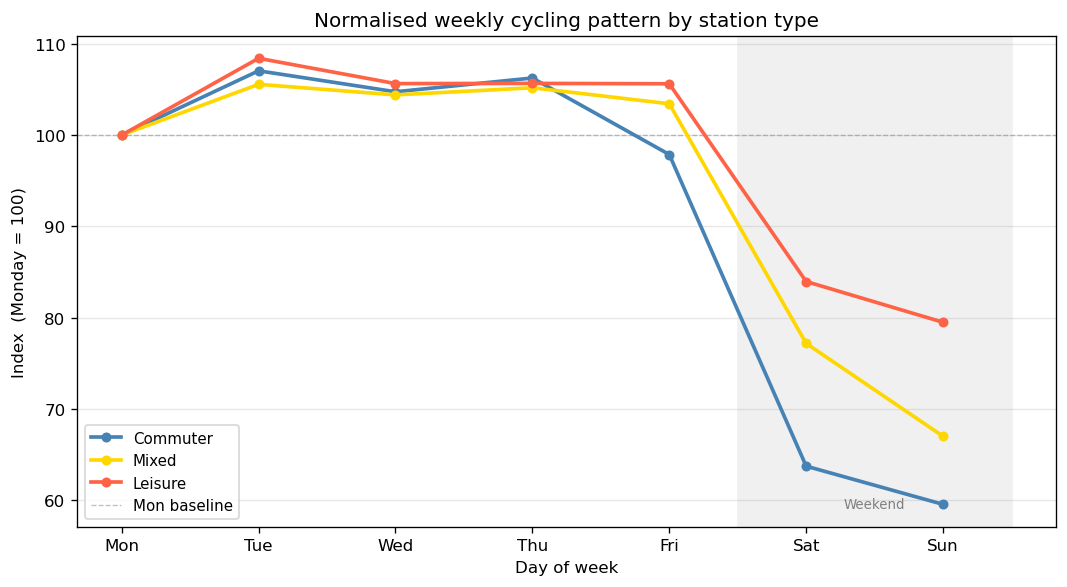

fig11_weekday_pattern_by_type.png saved.


In [13]:
# ── fig11: normalised weekly pattern by type ──────────────────────────────────
wd_pat = (
    panel_good.groupby(["site_type", "dayofweek"])["aantal"]
    .mean()
    .reset_index()
)
pivot = (
    wd_pat.pivot(index="dayofweek", columns="site_type", values="aantal")
    .reindex(columns=TYPE_ORDER)
)
# Index to Monday = 100 so shapes are comparable regardless of volume
pivot_norm = pivot.div(pivot.loc[0]) * 100

DAY_LABELS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
fig, ax = plt.subplots(figsize=(9, 5))
for stype, color in TYPE_COLORS.items():
    ax.plot(pivot_norm.index, pivot_norm[stype],
            color=color, lw=2.2, marker="o", ms=5, label=stype.title(), zorder=3)

ax.axhline(100, color="grey", lw=0.8, ls="--", alpha=0.5, label="Mon baseline")
ax.axvspan(4.5, 6.5, color="#f0f0f0", zorder=0)
ax.text(5.5, ax.get_ylim()[0] + 2, "Weekend", ha="center", fontsize=8, color="grey")
ax.set_xticks(range(7))
ax.set_xticklabels(DAY_LABELS)
ax.set_xlabel("Day of week")
ax.set_ylabel("Index  (Monday = 100)")
ax.set_title("Normalised weekly cycling pattern by station type")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(FIGS / "fig11_weekday_pattern_by_type.png", dpi=150)
plt.show()
print("fig11_weekday_pattern_by_type.png saved.")

/var/folders/99/f5nk7g8n09g1gdgwc7k9scjc0000gn/T/ipykernel_29579/848958433.py:37: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  Patch(color="grey", alpha=0.4, hatch="//", edgecolor="grey", label="School holiday"),


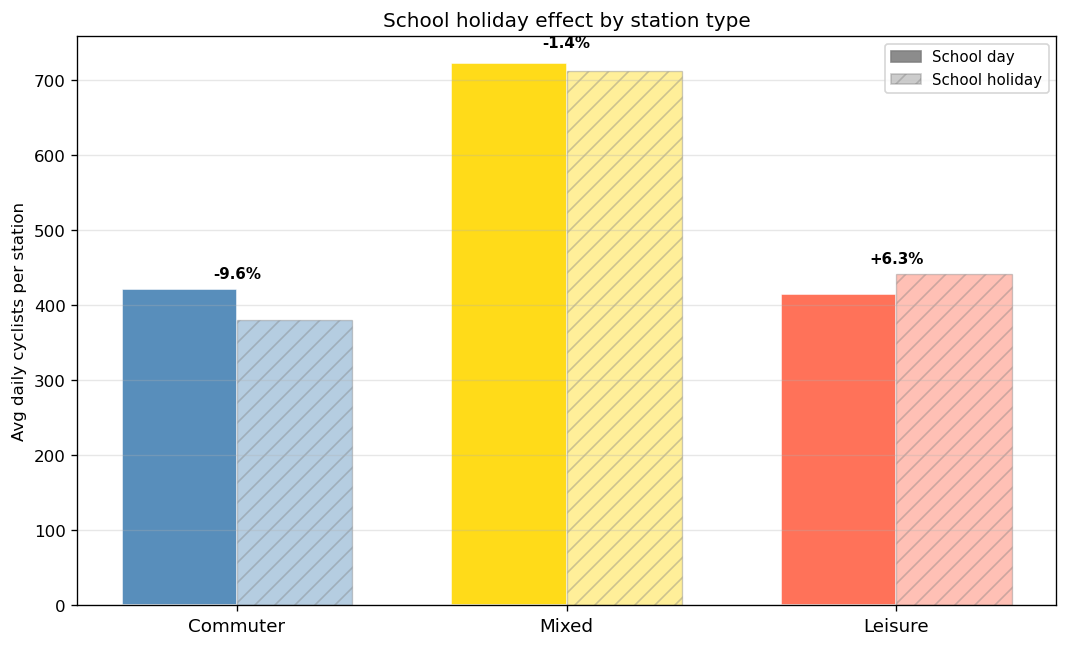

fig12_school_holiday_effect_by_type.png saved.


In [14]:
# ── fig12: school holiday effect by type ──────────────────────────────────────
school_avg = (
    panel_good.groupby(["site_type", "is_school_holiday"])["aantal"]
    .mean()
    .unstack()
    .rename(columns={False: "school_day", True: "school_holiday"})
    .reindex(TYPE_ORDER)
)
pct_change = ((school_avg["school_holiday"] - school_avg["school_day"])
              / school_avg["school_day"] * 100)

x     = np.arange(len(TYPE_ORDER))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5.5))
for i, (stype, color) in enumerate(zip(TYPE_ORDER, ["steelblue", "gold", "tomato"])):
    ax.bar(x[i] - width / 2, school_avg.loc[stype, "school_day"],
           width, color=color, alpha=0.9, edgecolor="white")
    ax.bar(x[i] + width / 2, school_avg.loc[stype, "school_holiday"],
           width, color=color, alpha=0.4, edgecolor="grey", lw=0.8, hatch="//")

    # % change label above each pair
    y_top = max(school_avg.loc[stype, "school_day"],
                school_avg.loc[stype, "school_holiday"])
    sign  = "+" if pct_change[stype] >= 0 else ""
    ax.text(x[i], y_top * 1.025,
            f"{sign}{pct_change[stype]:.1f}%",
            ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels([t.title() for t in TYPE_ORDER], fontsize=11)
ax.set_ylabel("Avg daily cyclists per station")
ax.set_title("School holiday effect by station type")
ax.grid(axis="y", alpha=0.3)
legend_handles = [
    Patch(color="grey", alpha=0.9, label="School day"),
    Patch(color="grey", alpha=0.4, hatch="//", edgecolor="grey", label="School holiday"),
]
ax.legend(handles=legend_handles, fontsize=9)
fig.tight_layout()
fig.savefig(FIGS / "fig12_school_holiday_effect_by_type.png", dpi=150)
plt.show()
print("fig12_school_holiday_effect_by_type.png saved.")

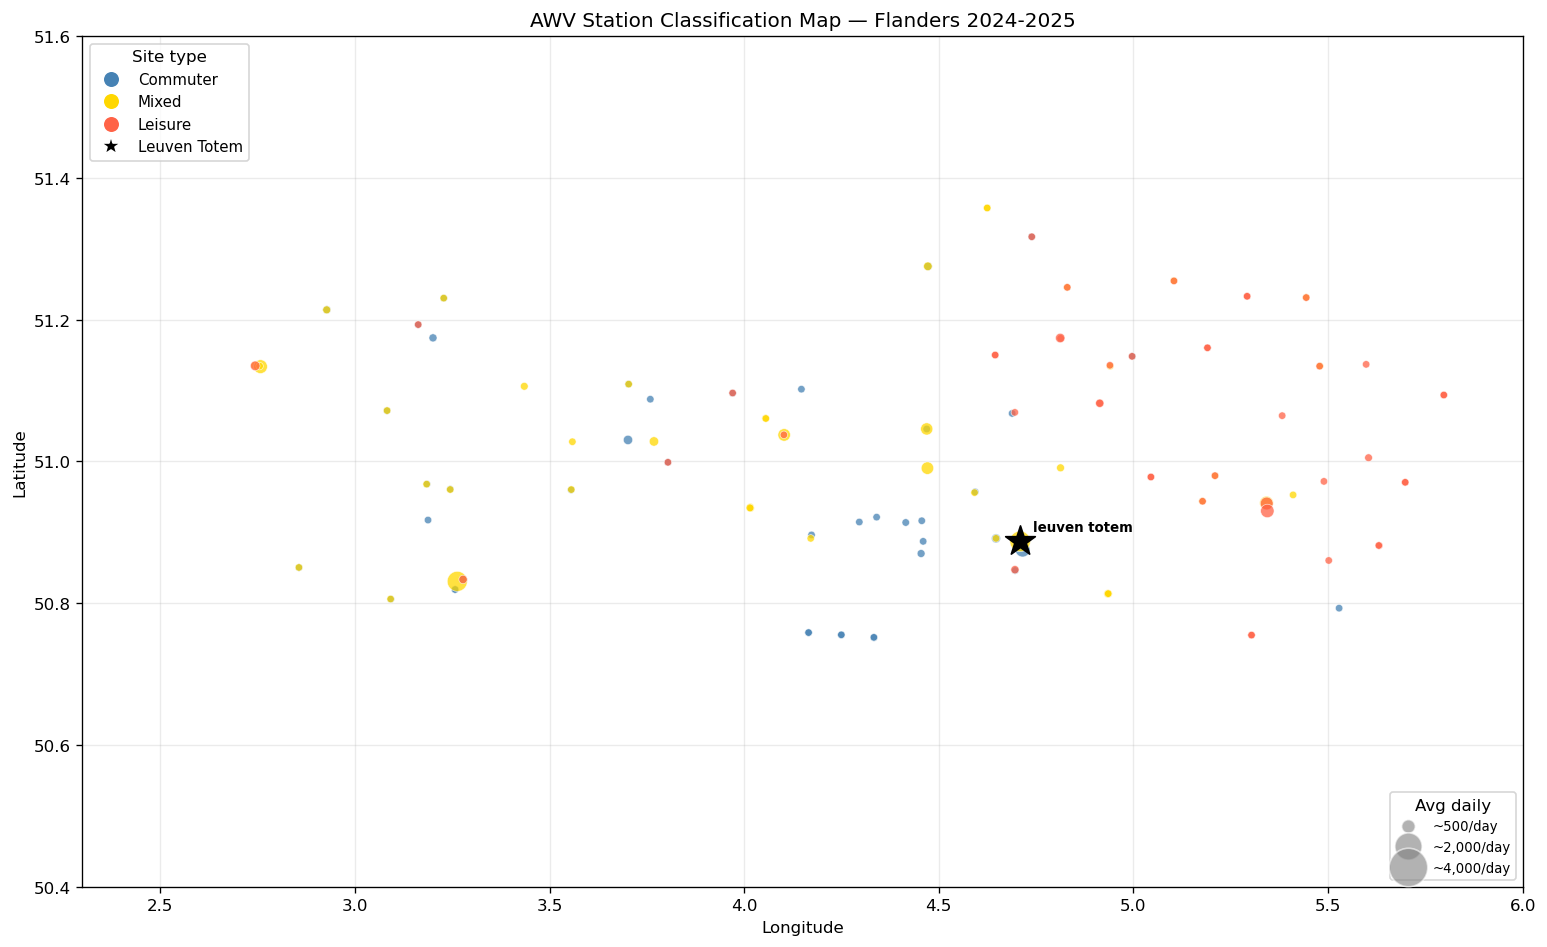

fig13_map_station_types.png saved.


In [15]:
# ── fig13: geographic map of station types ────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 8))

for stype, color in TYPE_COLORS.items():
    sub = site_stats[site_stats["site_type"] == stype]
    ax.scatter(
        sub["lon"], sub["lat"],
        c=color, s=(sub["avg_daily"] / 30).clip(20, 400),
        alpha=0.75, zorder=3, edgecolors="white", lw=0.4,
    )

# Leuven Totem star
totem = site_stats[site_stats["site ID"] == 107].iloc[0]
ax.scatter(totem["lon"], totem["lat"],
           marker="*", s=350, c="black", zorder=5)
ax.annotate("leuven totem",
            xy=(totem["lon"], totem["lat"]),
            xytext=(8, 6), textcoords="offset points",
            fontsize=8, fontweight="bold")

# Type legend
type_handles = [
    Line2D([0], [0], marker="o", color="w",
           markerfacecolor=c, markersize=10, label=t.title())
    for t, c in TYPE_COLORS.items()
]
type_handles.append(
    Line2D([0], [0], marker="*", color="w",
           markerfacecolor="black", markersize=12, label="Leuven Totem")
)

# Size legend
size_handles = [
    Line2D([0], [0], marker="o", color="w",
           markerfacecolor="grey", alpha=0.6,
           markersize=np.sqrt(s / 30) * 2, label=f"~{s:,}/day")
    for s in [500, 2000, 4000]
]

leg1 = ax.legend(handles=type_handles, fontsize=9,
                 title="Site type", loc="upper left")
ax.add_artist(leg1)
ax.legend(handles=size_handles, fontsize=8,
          title="Avg daily", loc="lower right")

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("AWV Station Classification Map — Flanders 2024-2025", fontsize=12)
ax.set_xlim(2.3, 6.0)
ax.set_ylim(50.4, 51.6)
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(FIGS / "fig13_map_station_types.png", dpi=150)
plt.show()
print("fig13_map_station_types.png saved.")

## 7. Save Classification Results

In [16]:
# Overwrite analysis_panel with enriched version (adds commute_score, site_type)
panel_full.to_parquet(PROCESSED / "analysis_panel.parquet", index=False)
site_stats.to_parquet(PROCESSED / "site_classification.parquet", index=False)

orig_cols   = list(panel.columns)
new_cols    = [c for c in panel_full.columns if c not in orig_cols]
sz_panel_mb = (PROCESSED / "analysis_panel.parquet").stat().st_size  / 1_048_576
sz_class_mb = (PROCESSED / "site_classification.parquet").stat().st_size / 1_048_576

print(f"analysis_panel.parquet updated")
print(f"  Shape     : {panel_full.shape}")
print(f"  New cols  : {new_cols}")
print(f"  File size : {sz_panel_mb:.1f} MB")
print()
print(f"site_classification.parquet")
print(f"  Shape     : {site_stats.shape}")
print(f"  Columns   : {list(site_stats.columns)}")
print(f"  File size : {sz_class_mb:.1f} MB")

analysis_panel.parquet updated
  Shape     : (108919, 56)
  New cols  : ['commute_score', 'site_type']
  File size : 4.8 MB

site_classification.parquet
  Shape     : (132, 18)
  Columns   : ['site ID', 'naam', 'gemeente', 'avg_daily', 'avg_peak_ratio', 'lon', 'lat', 'avg_weekday', 'avg_weekend', 'avg_schoolday', 'avg_schoolhol', 'weekday_weekend_ratio', 'school_retention', 'norm_wwr', 'norm_peak', 'norm_school', 'commute_score', 'site_type']
  File size : 0.0 MB


## 8. Summary

In [17]:
n_classified = len(site_stats)
type_ct      = site_stats["site_type"].value_counts()
n_low_cov    = panel["site ID"].nunique() - n_classified

totem       = site_stats[site_stats["site ID"] == 107].iloc[0]
sorted_s    = site_stats.sort_values("commute_score", ascending=False).reset_index(drop=True)
sorted_s.index += 1
totem_rank  = int(sorted_s.index[sorted_s["site ID"] == 107][0])

print("=" * 52)
print("SITE CLASSIFICATION SUMMARY")
print("=" * 52)
print(f"Total stations analysed : {n_classified} (well-covered only)")
print()
print("Classification results:")
for stype in ["commuter", "mixed", "leisure"]:
    n = type_ct.get(stype, 0)
    print(f"  {stype:<15} : {n:>3} stations ({n / n_classified * 100:.1f}%)")
print(f"  {'unclassified':<15} : {n_low_cov:>3} stations "
      f"(low-coverage, excluded)")
print()
print("Key metric averages by type:")
display(val_table.round(2))
print()
print(f"Leuven Totem (site ID 107):")
print(f"  commute_score         : {totem['commute_score']:.3f}"
      f"  (rank #{totem_rank}/{n_classified})")
print(f"  site_type             : {totem['site_type']}")
print(f"  weekday/weekend ratio : {totem['weekday_weekend_ratio']:.2f}")
print(f"  peak_ratio (avg)      : {totem['avg_peak_ratio']:.3f}")
print(f"  school_retention      : {totem['school_retention']:.3f}")
interpretation = (
    "Confirmed as commuter site — high weekday/weekend ratio, "
    "elevated peak share." if totem["site_type"] == "commuter"
    else "Unexpected classification — inspect metric values above."
)
print(f"  -> {interpretation}")
print()
print("Figures saved:")
for fn in ["fig10_classification_scatter.png",
           "fig11_weekday_pattern_by_type.png",
           "fig12_school_holiday_effect_by_type.png",
           "fig13_map_station_types.png"]:
    sz = (FIGS / fn).stat().st_size // 1024
    print(f"  {fn}  ({sz} KB)")
print("=" * 52)

SITE CLASSIFICATION SUMMARY
Total stations analysed : 132 (well-covered only)

Classification results:
  commuter        :  44 stations (33.3%)
  mixed           :  44 stations (33.3%)
  leisure         :  44 stations (33.3%)
  unclassified    :  17 stations (low-coverage, excluded)

Key metric averages by type:


,avg_weekday,avg_weekend,avg_schoolday,avg_schoolhol,avg_peak_ratio,wday_wend_ratio,school_drop_pct
site_type,,,,,,,
commuter,462.869995,276.519989,421.630005,380.970001,0.31,1.67,9.64
mixed,788.270020,547.950012,722.830017,712.580017,0.27,1.44,1.42
leisure,450.940002,350.779999,414.820007,441.059998,0.22,1.29,-6.33



Leuven Totem (site ID 107):
  commute_score         : 0.343  (rank #49/132)
  site_type             : mixed
  weekday/weekend ratio : 1.49
  peak_ratio (avg)      : 0.301
  school_retention      : 0.900
  -> Unexpected classification — inspect metric values above.

Figures saved:
  fig10_classification_scatter.png  (109 KB)
  fig11_weekday_pattern_by_type.png  (87 KB)
  fig12_school_holiday_effect_by_type.png  (62 KB)
  fig13_map_station_types.png  (89 KB)
